# ✦ NHANES Attention / Processing Speed Output Analysis

## Finding the Minimum, Maximum, and Descriptive Statistics for Attention Speed Scores

This notebook analyzes the attention / processing speed output variable for the sleep installation.

The goal is to understand the range of attention-speed test results that can be used to control the reaction-speed game.

The NHANES variable is:

| Variable | Meaning                         |
| -------- | ------------------------------- |
| CFDDS    | Digit Symbol Substitution score |

In this project, we use this variable as:

**attention_speed_score**

This variable represents processing speed / attention performance.

It is not a pure reaction-time measure, but it can still support the attention game because it reflects how quickly and accurately someone processes visual information.


In [1]:
from pathlib import Path
import requests
import pandas as pd
from tqdm.auto import tqdm

# Find the main project folder.
# This is useful because this notebook is inside the Notebooks folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# Create organized folders
DATA_DIR = PROJECT_DIR / "data" / "nhanes"
GRAPH_DIR = PROJECT_DIR / "Graphs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", CURRENT_DIR)
print("Project folder:", PROJECT_DIR)
print("NHANES data folder:", DATA_DIR)
print("Graph folder:", GRAPH_DIR)

Current folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Notebooks
Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
NHANES data folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\nhanes
Graph folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs


---

# 2. ✧ Loading the NHANES Cognitive Functioning Dataset

For the attention / processing speed output variable, we use the NHANES cognitive functioning dataset.

The variable we need is:

| Variable | Meaning                         |
| -------- | ------------------------------- |
| CFDDS    | Digit Symbol Substitution score |

In this project, we rename this variable to:

**attention_speed_score**

This score will be used as the output variable for the attention / reaction-speed game.


In [2]:
# NHANES 2011–2012 Cognitive Functioning file
CFQ_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/CFQ_G.XPT"

CFQ_FILE = DATA_DIR / "CFQ_G.XPT"

def download_file(url, destination):
    if destination.exists():
        print("File already exists, skipping download:")
        print(destination)
        return

    print("Downloading file...")
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(destination, "wb") as file, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print("Download finished!")

download_file(CFQ_URL, CFQ_FILE)

# Load the NHANES XPT file
attention_df = pd.read_sas(CFQ_FILE, format="xport")

print("Rows:", len(attention_df))
print("Columns:", len(attention_df.columns))

attention_df.head()

Downloading:   0%|          | 0.00/26.6k [00:00<?, ?B/s]

Download finished!
Rows: 1687
Columns: 19


,SEQN,CFASTAT,CFALANG,CFDCCS,CFDCRNC,CFDCST1,CFDCST2,CFDCST3,CFDCSR,CFDCIT1,CFDCIT2,CFDCIT3,CFDCIR,CFDAPP,CFDARNC,CFDAST,CFDDPP,CFDDRNC,CFDDS
0,62174.0,1.0,1.0,1.0,NaN,3.0,6.0,7.0,5.0,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,1.0,NaN,18.0,1.0,NaN,33.0
1,62178.0,1.0,1.0,1.0,NaN,3.0,5.0,5.0,3.0,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,1.0,NaN,12.0,1.0,NaN,38.0
2,62191.0,1.0,1.0,1.0,NaN,4.0,5.0,7.0,5.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,17.0,1.0,NaN,26.0
3,62209.0,1.0,2.0,1.0,NaN,3.0,3.0,5.0,3.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,15.0,2.0,NaN,NaN
4,62215.0,1.0,1.0,1.0,NaN,5.0,8.0,8.0,7.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,15.0,1.0,NaN,47.0


---

# 3. ✧ Selecting and Describing the Attention Speed Variable

Now we select the NHANES attention / processing speed variable.

The original NHANES variable is:

**CFDDS**

In this notebook, we rename it to:

**attention_speed_score**

This variable represents Digit Symbol Substitution performance.

Higher scores mean better processing speed / attention performance.

This step calculates the first descriptive statistics:

| Statistic          | Meaning                       |
| ------------------ | ----------------------------- |
| Count              | Number of valid participants  |
| Minimum            | Lowest attention speed score  |
| Median             | Middle attention speed score  |
| Mean               | Average attention speed score |
| Maximum            | Highest attention speed score |
| Standard deviation | Spread between participants   |

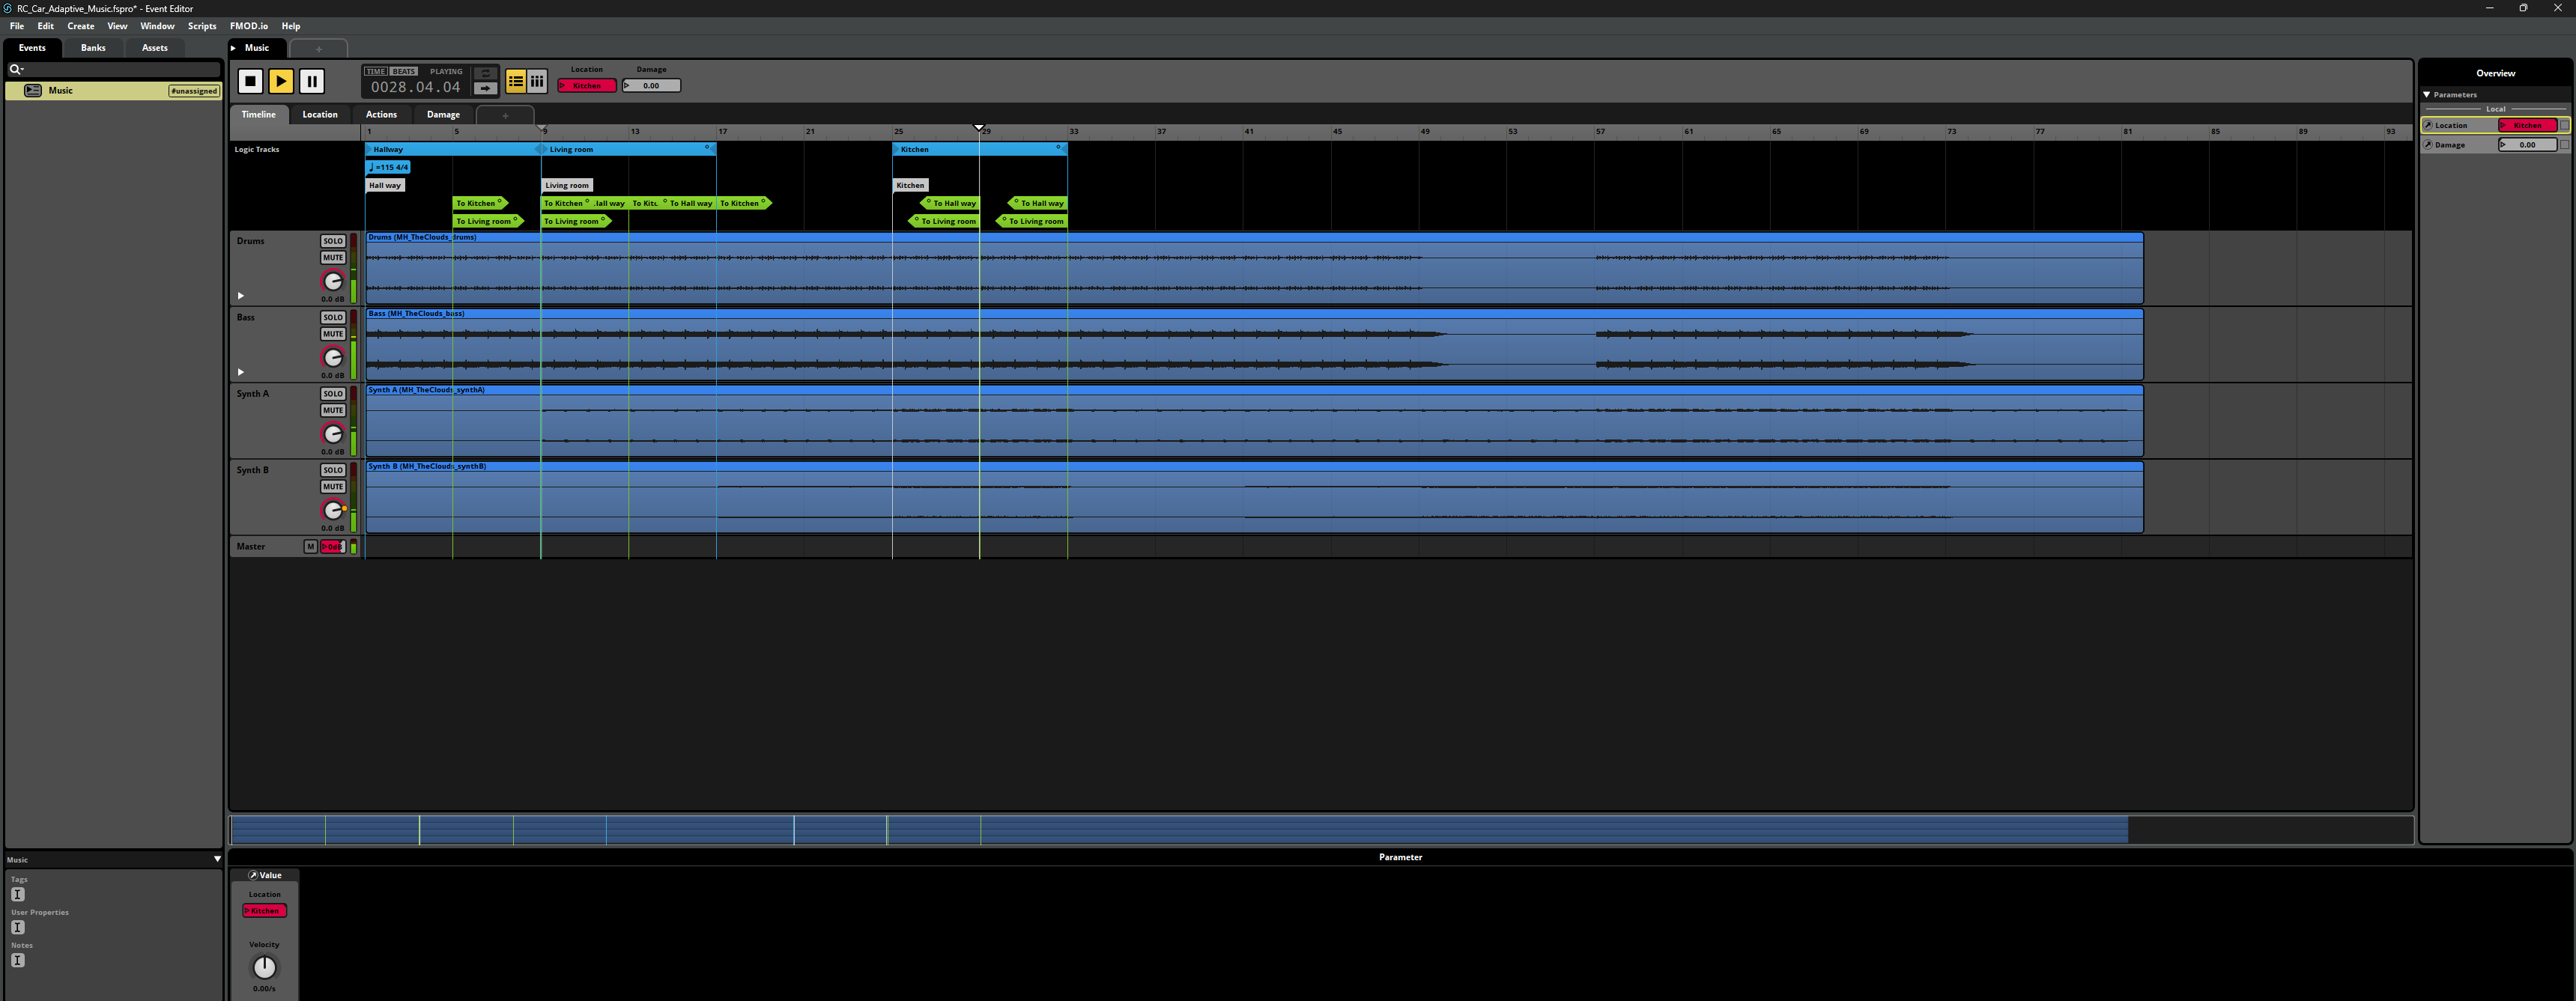

In [3]:
# ------------------------------------------------------------
# Select and prepare attention / processing speed variable
# ------------------------------------------------------------

# Check whether the needed column exists
if "CFDDS" in attention_df.columns:
    print("CFDDS column found!")
else:
    print("CFDDS column not found. Available columns are:")
    print(attention_df.columns.tolist())

# Select participant ID and attention speed variable
attention_analysis = attention_df[
    [
        "SEQN",
        "CFDDS"
    ]
].copy()

# Rename variable for the project
attention_analysis = attention_analysis.rename(
    columns={
        "CFDDS": "attention_speed_score"
    }
)

# Convert to numeric
attention_analysis["attention_speed_score"] = pd.to_numeric(
    attention_analysis["attention_speed_score"],
    errors="coerce"
)

# Replace possible special missing codes with missing values
special_missing_codes = [77, 99, 7777, 9999]

attention_analysis["attention_speed_score"] = attention_analysis[
    "attention_speed_score"
].replace(
    special_missing_codes,
    pd.NA
)

print("\nMissing values before keeping valid cases:")
display(attention_analysis["attention_speed_score"].isna().sum())

# Keep only valid non-negative scores
attention_analysis = attention_analysis[
    attention_analysis["attention_speed_score"].notna() &
    (attention_analysis["attention_speed_score"] >= 0)
].copy()

attention_score = attention_analysis["attention_speed_score"]

print("\nAttention / processing speed descriptive statistics")
print("---------------------------------------------------")
print("Valid participants:", len(attention_analysis))
print("Minimum:", round(attention_score.min(), 2))
print("Maximum:", round(attention_score.max(), 2))
print("Mean:", round(attention_score.mean(), 2))
print("Median:", round(attention_score.median(), 2))
print("Standard deviation:", round(attention_score.std(), 2))

print("\nFull descriptive statistics:")
display(attention_score.describe())

# Create a clean table for display
attention_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(attention_score.count())} participants",
        f"{attention_score.min():.2f}",
        f"{attention_score.quantile(0.25):.2f}",
        f"{attention_score.median():.2f}",
        f"{attention_score.mean():.2f}",
        f"{attention_score.quantile(0.75):.2f}",
        f"{attention_score.max():.2f}",
        f"{attention_score.std():.2f}"
    ],
    "Simple meaning": [
        "Number of valid participants analyzed",
        "Lowest attention speed score",
        "25% of participants were at or below this value",
        "Middle attention speed score",
        "Average attention speed score",
        "75% of participants were at or below this value",
        "Highest attention speed score",
        "How spread out the attention speed scores are"
    ]
})

display(attention_stats_table)

CFDDS column found!

Missing values before keeping valid cases:


np.int64(275)


Attention / processing speed descriptive statistics
---------------------------------------------------
Valid participants: 1412
Minimum: 0.0
Maximum: 100.0
Mean: 44.69
Median: 44.0
Standard deviation: 17.51

Full descriptive statistics:


count     1412.0
unique      91.0
top         49.0
freq        40.0
Name: attention_speed_score, dtype: float64

,Statistic,Value,Simple meaning
0,Count,1412 participants,Number of valid participants analyzed
1,Minimum,0.00,Lowest attention speed score
2,25th percentile,32.00,25% of participants were at or below this value
3,Median,44.00,Middle attention speed score
4,Mean,44.69,Average attention speed score
5,75th percentile,57.25,75% of participants were at or below this value
6,Maximum,100.00,Highest attention speed score
7,Standard deviation,17.51,How spread out the attention speed scores are


---

# 4. ✧ Graphing the Attention / Processing Speed Distribution

Now we create a distribution graph for the attention / processing speed output variable.

The variable is:

**attention_speed_score**

This graph shows how participants are distributed across the attention-speed score range.

Higher scores represent better processing speed / attention performance.


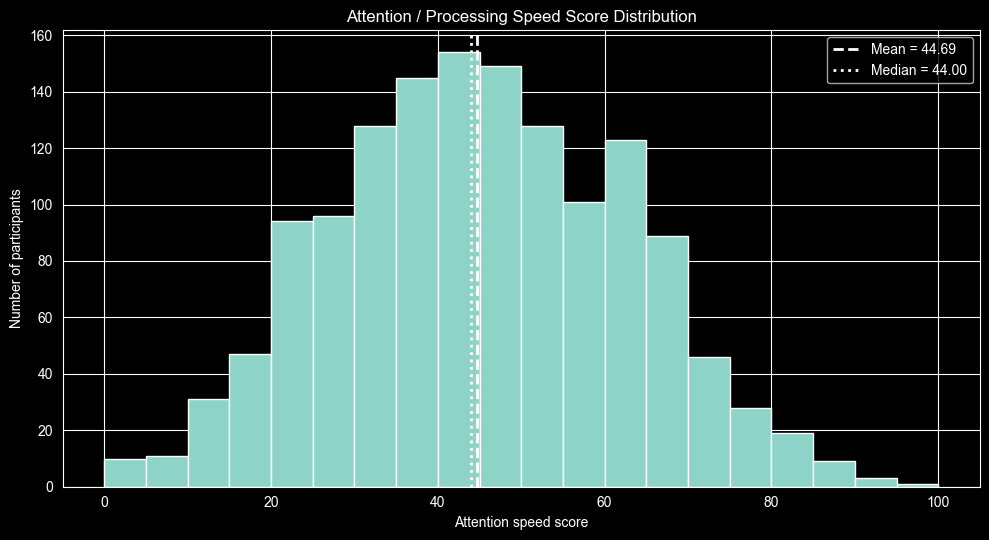

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\attention_speed_score_distribution.png


In [4]:
import matplotlib.pyplot as plt

# Select attention speed score values
attention_score = attention_analysis["attention_speed_score"].dropna()

# Create the graph
plt.figure(figsize=(10, 5.5))

plt.hist(attention_score, bins=20)

plt.axvline(
    attention_score.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {attention_score.mean():.2f}"
)

plt.axvline(
    attention_score.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {attention_score.median():.2f}"
)

plt.title("Attention / Processing Speed Score Distribution")
plt.xlabel("Attention speed score")
plt.ylabel("Number of participants")
plt.legend()
plt.tight_layout()

# Save the graph
attention_graph_path = GRAPH_DIR / "attention_speed_score_distribution.png"
plt.savefig(attention_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(attention_graph_path)